In [1]:
import pandas as pd

In [2]:
df=pd.read_csv(r"C:\Users\user\OneDrive\Desktop\European_Bank.csv")

In [3]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
df=df.drop(["CustomerId","Surname"], axis=1)
df.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
x=df.drop("Exited", axis=1)
y=df["Exited"]
print(x.shape)
print(y.shape)

(10000, 11)
(10000,)


In [10]:
x["BalanceSalaryRatio"]=x["Balance"]/(x["EstimatedSalary"]+1)
x["ProductDensity"]=x["NumOfProducts"]/(x["Tenure"]+1)
x["EngagementProduct"]=x["IsActiveMember"]*x["NumOfProducts"]
x["AgeTenure"]=x["Age"]*x["Tenure"]
x.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,BalanceSalaryRatio,ProductDensity,EngagementProduct,AgeTenure
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,0.000000,0.333333,1,84
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0.744670,0.500000,1,41
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1.401362,0.333333,0,336
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0.000000,1.000000,0,39
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,1.587035,0.333333,1,86


In [11]:
x=pd.get_dummies(x,drop_first=True)

In [12]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test=train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(x_train.shape)
print(x_test.shape)

(8000, 16)
(2000, 16)


In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
print(x_train.head())
x_train_scaled =scaler.fit_transform(x_train)
x_test_scaled =scaler.transform(x_test)
print(x_train_scaled.shape)

      Year  CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
2151  2025          753   57       7       0.00              1          1   
8392  2025          739   32       3  102128.27              1          1   
5006  2025          755   37       0  113865.23              2          1   
4117  2025          561   37       5       0.00              2          1   
7182  2025          692   49       6  110540.43              2          0   

      IsActiveMember  EstimatedSalary  BalanceSalaryRatio  ProductDensity  \
2151               0        159475.08            0.000000        0.125000   
8392               0         63981.37            1.596194        0.250000   
5006               1        117396.25            0.969914        2.000000   
4117               0         83093.25            0.000000        0.333333   
7182               1        107472.99            1.028532        0.285714   

      EngagementProduct  AgeTenure  Geography_Germany  Geography_Spain  \


In [14]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [15]:
y_pred = log_model.predict(x_test_scaled)

y_prob = log_model.predict_proba(x_test_scaled)

In [16]:
print(y_pred[:30])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]


In [17]:
print(y_prob[:10])

[[0.88970998 0.11029002]
 [0.73798082 0.26201918]
 [0.87733725 0.12266275]
 [0.8625184  0.1374816 ]
 [0.91316651 0.08683349]
 [0.85078669 0.14921331]
 [0.90543258 0.09456742]
 [0.63002603 0.36997397]
 [0.63033173 0.36966827]
 [0.78387803 0.21612197]]


In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8065


In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1535   58]
 [ 329   78]]


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.96      0.89      1593
           1       0.57      0.19      0.29       407

    accuracy                           0.81      2000
   macro avg       0.70      0.58      0.59      2000
weighted avg       0.77      0.81      0.77      2000



In [21]:
from sklearn.metrics import roc_auc_score
y_prob= log_model.predict_proba(x_test_scaled)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.773440620898248


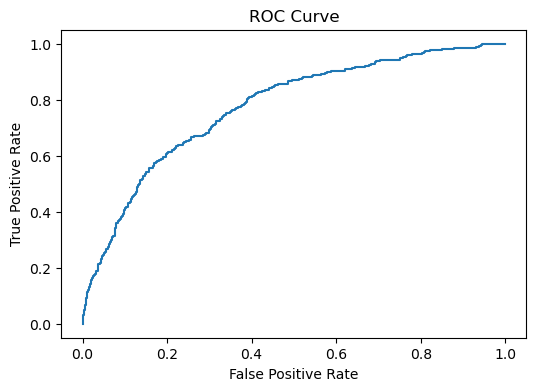

In [22]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [23]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:
y_pred_dt = dt_model.predict(x_test)

y_prob_dt = dt_model.predict_proba(x_test)[:,1]

In [25]:
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7885


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.87      0.86      0.87      1593
           1       0.48      0.49      0.49       407

    accuracy                           0.79      2000
   macro avg       0.68      0.68      0.68      2000
weighted avg       0.79      0.79      0.79      2000



In [27]:
from sklearn.metrics import roc_auc_score

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_dt))

ROC-AUC: 0.6779036355307543


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
y_pred_rf = rf_model.predict(x_test)

y_prob_rf = rf_model.predict_proba(x_test)[:,1]

In [30]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.865


In [31]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[1535   58]
 [ 212  195]]


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.77      0.48      0.59       407

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.76      2000
weighted avg       0.86      0.86      0.85      2000



In [33]:
from sklearn.metrics import roc_auc_score

roc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", roc_rf)

Random Forest ROC-AUC: 0.8502508672000197


In [34]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

               Feature  Importance
2                  Age    0.198365
1          CreditScore    0.104509
8      EstimatedSalary    0.102614
4              Balance    0.097922
5        NumOfProducts    0.094353
12           AgeTenure    0.091967
9   BalanceSalaryRatio    0.082616
11   EngagementProduct    0.045694
10      ProductDensity    0.045419
3               Tenure    0.038131


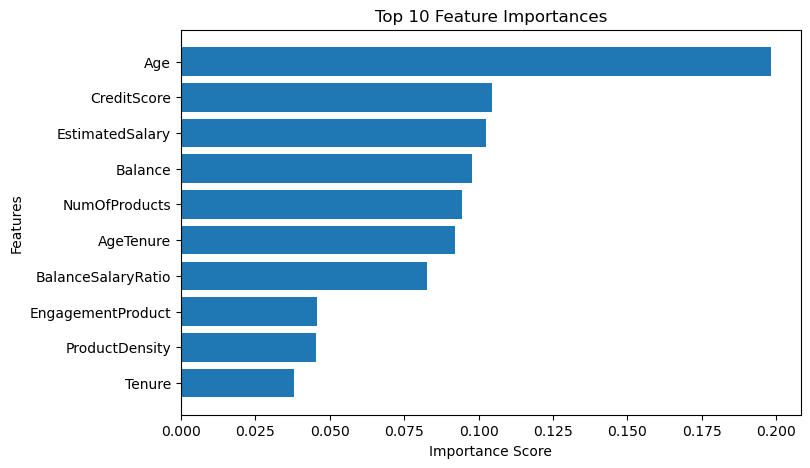

In [35]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(top_features["Feature"],
         top_features["Importance"])

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Feature Importances")

plt.gca().invert_yaxis()

plt.show()

In [36]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(x_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [37]:
y_pred_gb = gb_model.predict(x_test)

y_prob_gb = gb_model.predict_proba(x_test)[:,1]

In [38]:
from sklearn.metrics import accuracy_score

gb_accuracy = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.869


In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.79      0.49      0.60       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [40]:
from sklearn.metrics import roc_auc_score

roc_gb = roc_auc_score(y_test, y_prob_gb)

print("Gradient Boosting ROC-AUC:", roc_gb)

Gradient Boosting ROC-AUC: 0.868227241108597


In [41]:
gb_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': gb_model.feature_importances_
})

gb_importance = gb_importance.sort_values(
    by='Importance',
    ascending=False
)

print(gb_importance.head(10))

               Feature  Importance
2                  Age    0.386040
5        NumOfProducts    0.289161
7       IsActiveMember    0.069738
4              Balance    0.062369
13   Geography_Germany    0.059426
11   EngagementProduct    0.050400
9   BalanceSalaryRatio    0.023124
1          CreditScore    0.017146
8      EstimatedSalary    0.015842
15         Gender_Male    0.013189


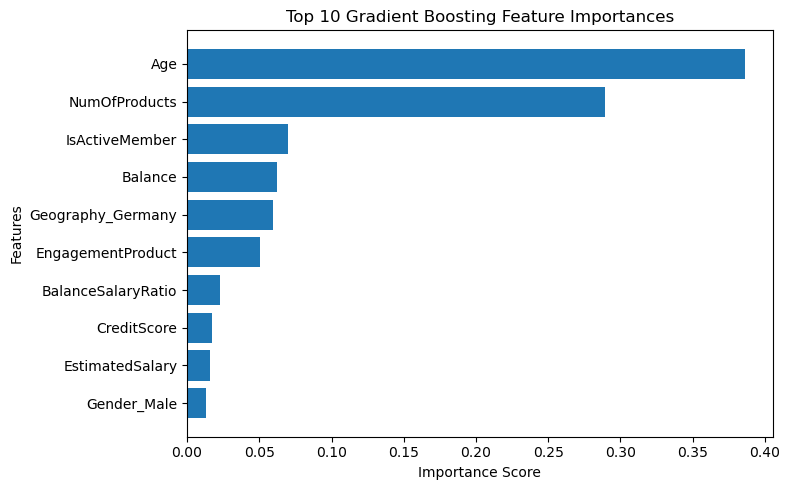

In [42]:
import matplotlib.pyplot as plt

top_gb_features = gb_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(top_gb_features["Feature"],
         top_gb_features["Importance"])

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Gradient Boosting Feature Importances")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [43]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],

    'Accuracy': [
        accuracy,
        accuracy_score(y_test, y_pred_dt),
        rf_accuracy,
        gb_accuracy
    ],

    'ROC-AUC': [
        roc_auc,
        roc_auc_score(y_test, y_prob_dt),
        roc_rf,
        roc_gb
    ]
})

print(model_results)

                 Model  Accuracy   ROC-AUC
0  Logistic Regression    0.8065  0.773441
1        Decision Tree    0.7885  0.677904
2        Random Forest    0.8650  0.850251
3    Gradient Boosting    0.8690  0.868227


Final Choice- Gradient Boosting

In [44]:
!pip install shap

In [45]:
import shap

In [46]:
explainer = shap.Explainer(gb_model)

shap_values = explainer(x_test)

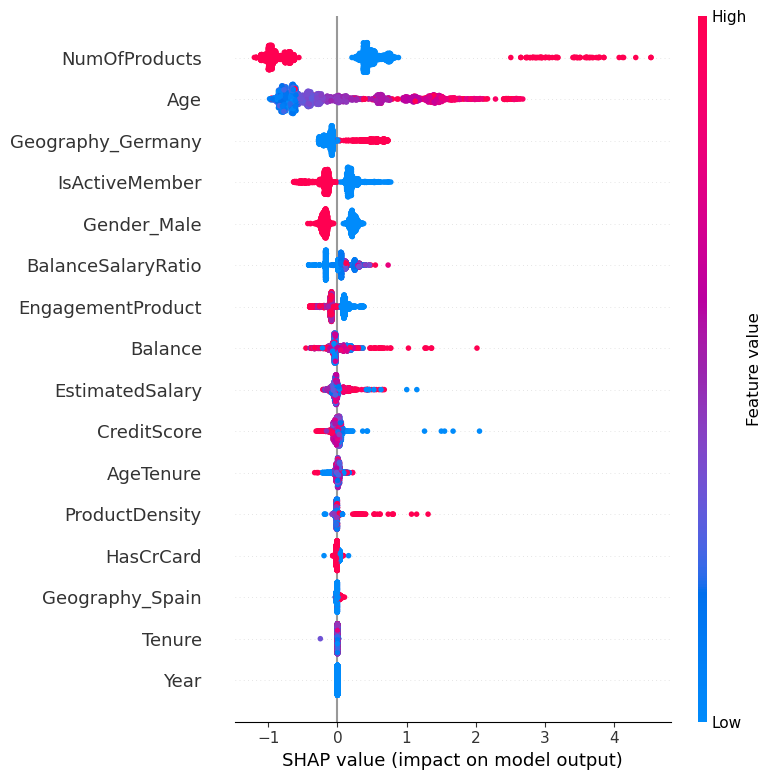

In [47]:
shap.summary_plot(shap_values, x_test)

customer is likely to churn mainly because:

they are inactive,
older,
and own only one product.

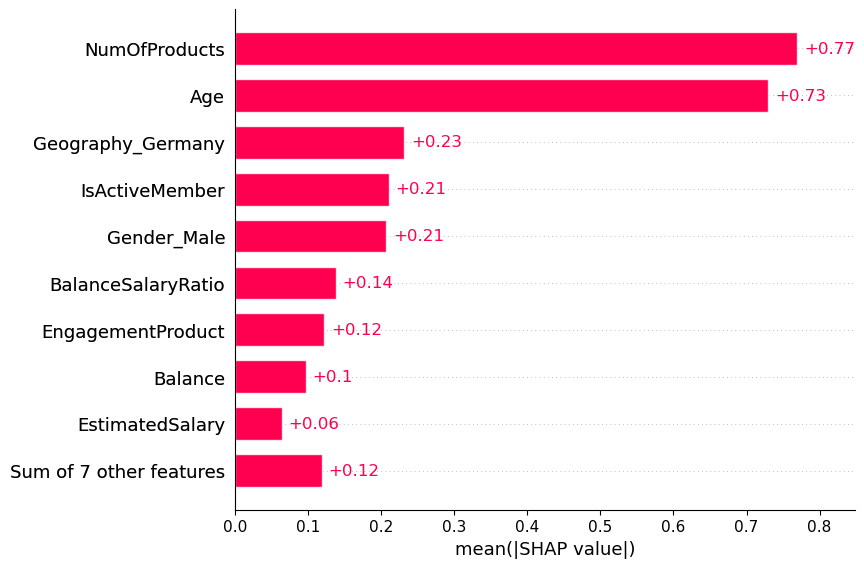

In [48]:
shap.plots.bar(shap_values)

risk_scores = pd.DataFrame({
    'Actual': y_test,
    'Predicted_Probability': y_prob_gb
})

def risk_category(prob):
    if prob < 0.30:
        return "Low Risk"
    elif prob < 0.60:
        return "Medium Risk"
    else:
        return "High Risk"

risk_scores["Risk_Category"] = risk_scores[
    "Predicted_Probability"
].apply(risk_category)

risk_scores.head()

In [49]:
import pickle

In [50]:
with open("gb_model.pkl", "wb") as file:
    pickle.dump(gb_model, file)

In [51]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [52]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'app.py', 'CustomerChurn.ipynb', 'European_Bank.csv', 'feature_names.pkl', 'gb_model.pkl', 'scaler.pkl']


In [53]:
feature_names = x.columns.tolist()

print(feature_names)

['Year', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalanceSalaryRatio', 'ProductDensity', 'EngagementProduct', 'AgeTenure', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']


In [54]:
with open("feature_names.pkl", "wb") as file:
    pickle.dump(feature_names, file)

In [55]:
import pickle

with open("feature_names.pkl", "wb") as file:
    pickle.dump(feature_names, file)

In [56]:
import seaborn as sns

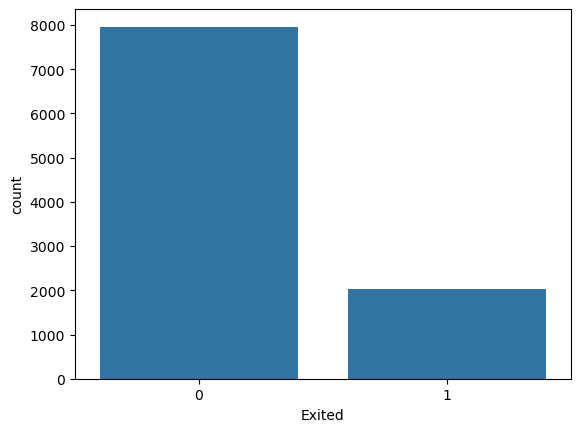

In [57]:
sns.countplot(x='Exited', data=df)
plt.show()

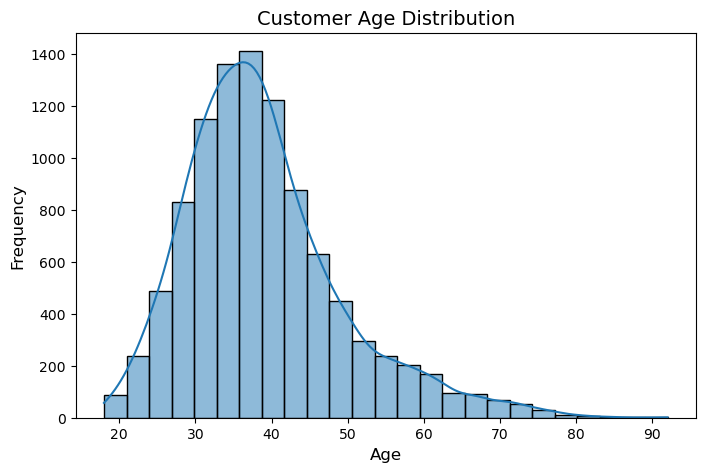

In [58]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=25, kde=True)

plt.title("Customer Age Distribution", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

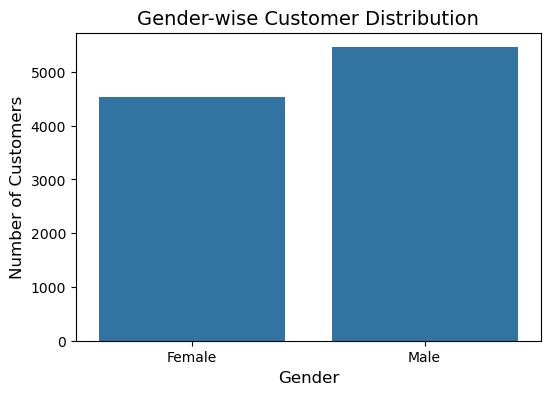

In [59]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title("Gender-wise Customer Distribution", fontsize=14)
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.show()

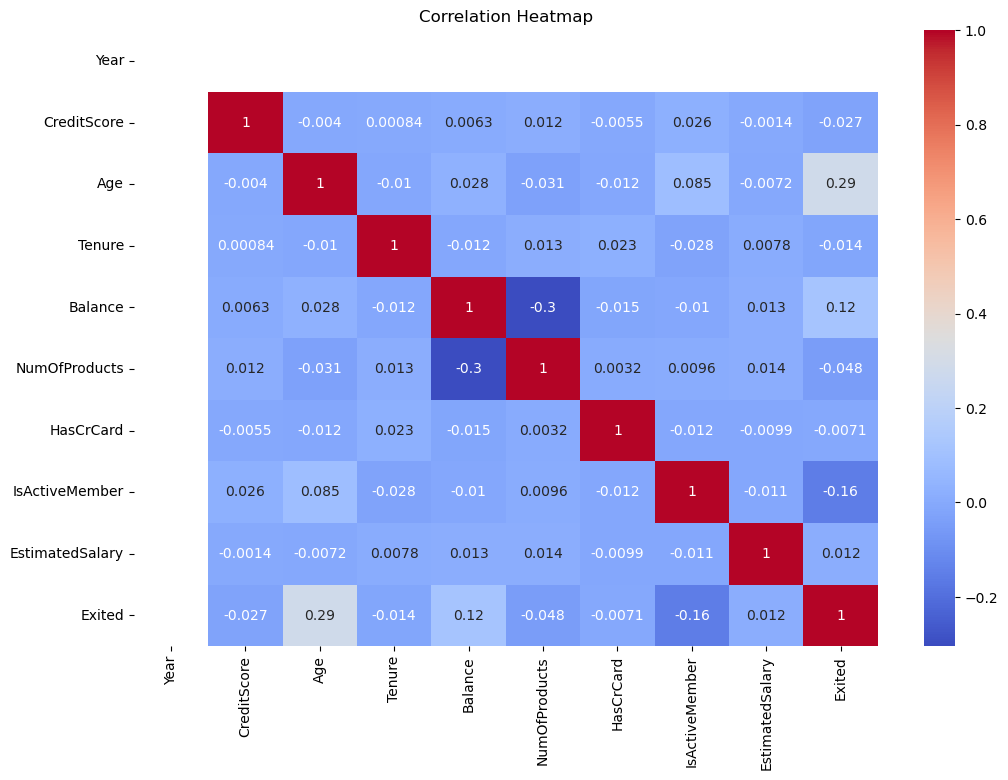

In [60]:
plt.figure(figsize=(12,8))

sns.heatmap(df.select_dtypes(include=['number']).corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

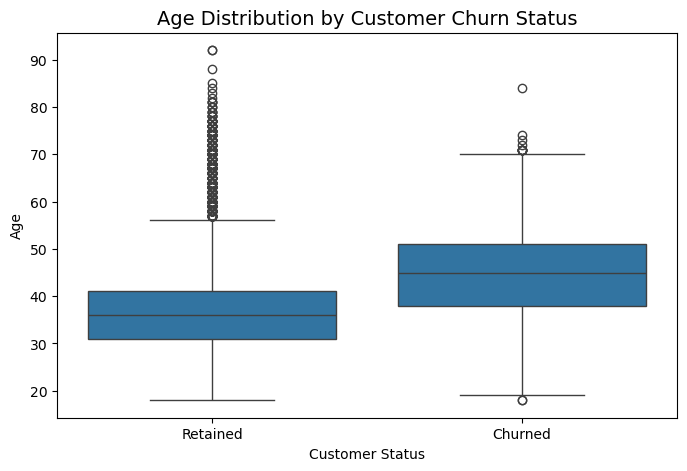

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Exited', y='Age', data=df)

plt.xticks([0,1], ['Retained','Churned'])

plt.title("Age Distribution by Customer Churn Status", fontsize=14)
plt.xlabel("Customer Status")
plt.ylabel("Age")

plt.show()

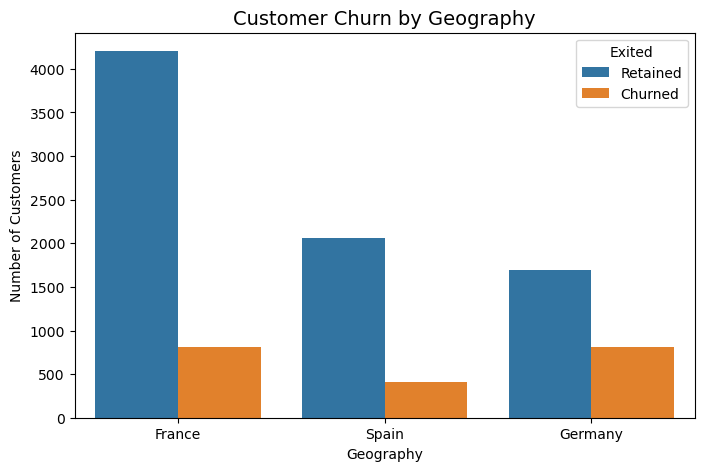

In [62]:
plt.figure(figsize=(8,5))

sns.countplot(x='Geography', hue='Exited', data=df)

plt.title("Customer Churn by Geography", fontsize=14)
plt.xlabel("Geography")
plt.ylabel("Number of Customers")

plt.legend(title='Exited', labels=['Retained','Churned'])

plt.show()

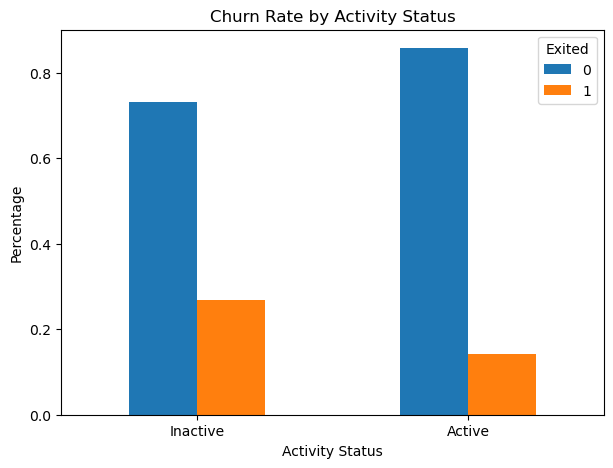

In [63]:
activity_churn = pd.crosstab(
    df['IsActiveMember'],
    df['Exited'],
    normalize='index'
)

activity_churn.plot(kind='bar',
                    figsize=(7,5))

plt.title('Churn Rate by Activity Status')
plt.xlabel('Activity Status')
plt.ylabel('Percentage')

plt.xticks([0,1], ['Inactive','Active'], rotation=0)

plt.show()

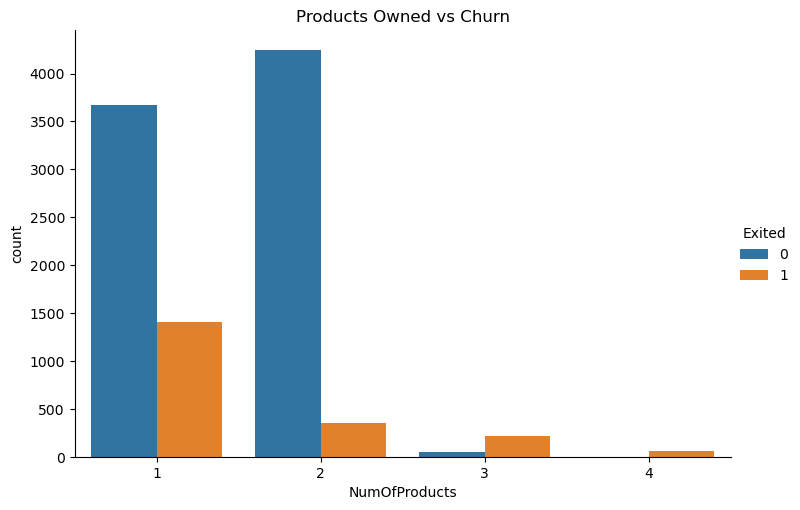

In [64]:
sns.catplot(
    data=df,
    x='NumOfProducts',
    hue='Exited',
    kind='count',
    height=5,
    aspect=1.5
)

plt.title('Products Owned vs Churn')

plt.show()

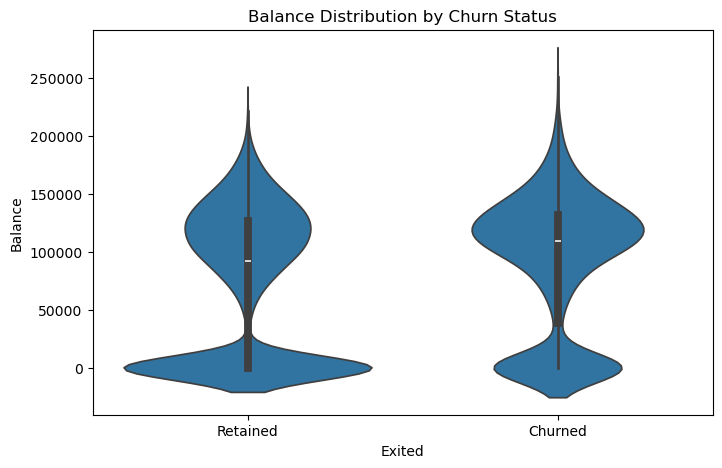

In [65]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='Exited',
    y='Balance'
)

plt.xticks([0,1], ['Retained','Churned'])

plt.title('Balance Distribution by Churn Status')

plt.show()

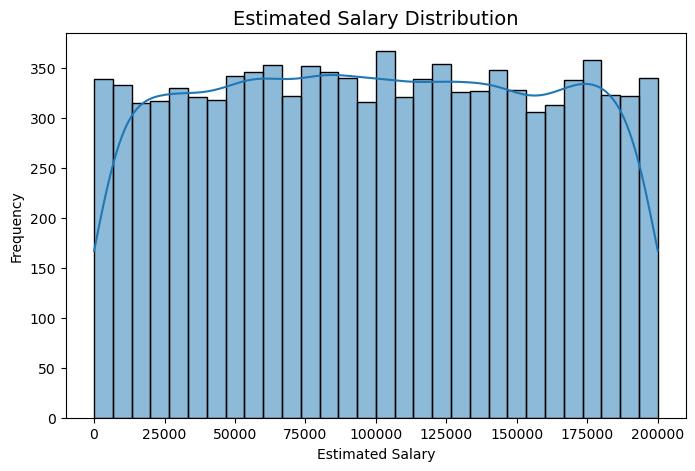

In [66]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='EstimatedSalary', bins=30, kde=True)

plt.title("Estimated Salary Distribution", fontsize=14)
plt.xlabel("Estimated Salary")
plt.ylabel("Frequency")

plt.show()

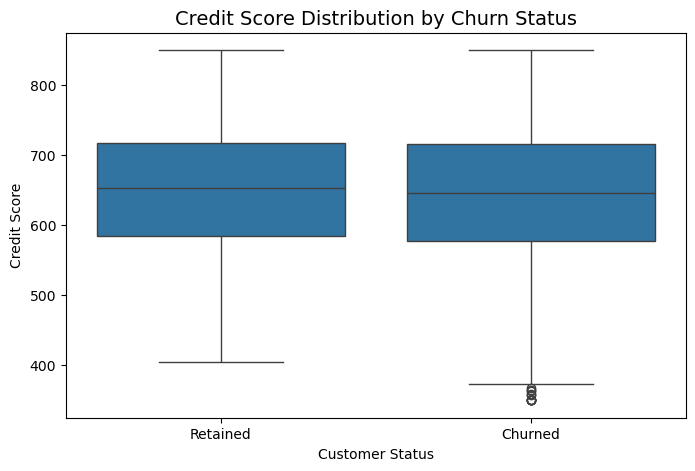

In [67]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Exited', y='CreditScore', data=df)

plt.xticks([0,1], ['Retained','Churned'])

plt.title("Credit Score Distribution by Churn Status", fontsize=14)
plt.xlabel("Customer Status")
plt.ylabel("Credit Score")

plt.show()

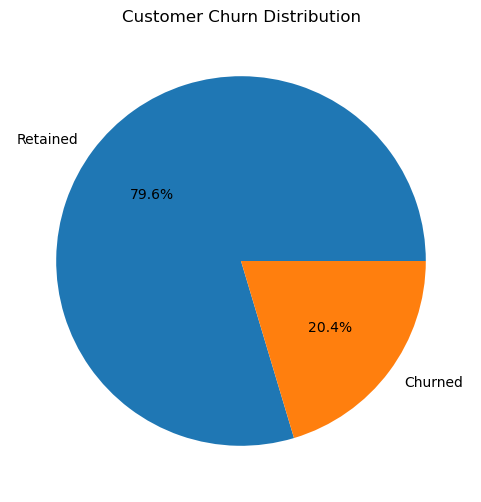

In [68]:
churn_counts = df['Exited'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(churn_counts,
        labels=['Retained','Churned'],
        autopct='%1.1f%%')

plt.title('Customer Churn Distribution')

plt.show()

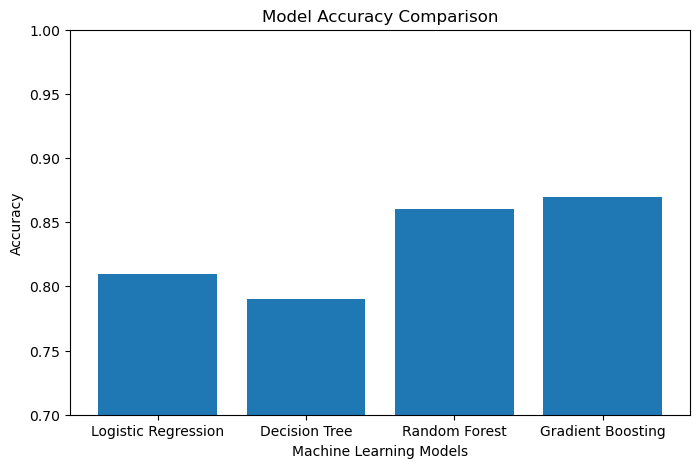

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree','Random Forest','Gradient Boosting'],
    'Accuracy':[0.81,0.79,0.86,0.87]
})

plt.figure(figsize=(8,5))
plt.bar(results['Model'], results['Accuracy'])

plt.title('Model Accuracy Comparison')
plt.xlabel('Machine Learning Models')
plt.ylabel('Accuracy')

plt.ylim(0.7,1.0)

plt.show()

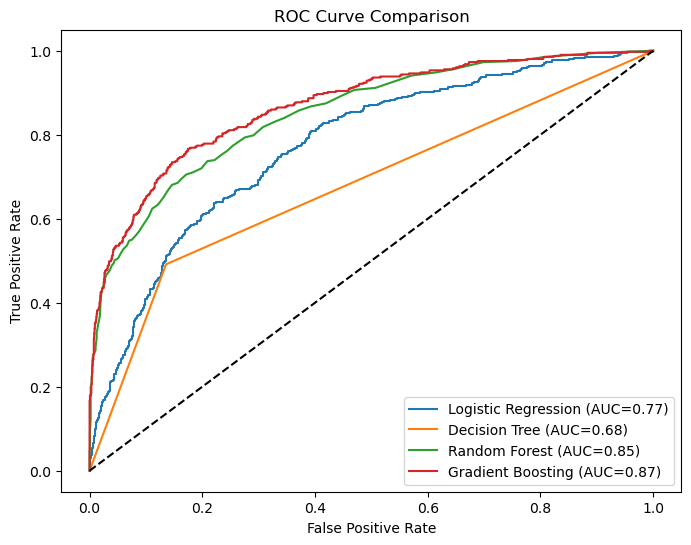

In [75]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
auc_lr = roc_auc_score(y_test, y_prob)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
auc_gb = roc_auc_score(y_test, y_prob_gb)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC={auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.2f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC={auc_gb:.2f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()

plt.show()

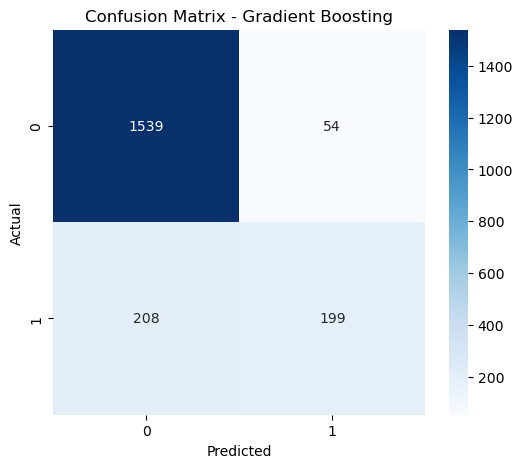

In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()